# 6/26 Razor Test 1
### Notes:
Collimitor face to reflection off wedge 95mm  
Wedge to mirror 135mm  
Mirror to lens 142mm  
Lens to blade 66 mm  
Blad e4to sensor 200mm  
Focal length 50mm 1in dia  
Computational dist:     |   d1: 326.57  (320.5 face to d1)|   d2: 55.32 |   Path: 375.82  
Measured distances:     |   d1: (372)                     |   d2: 66    |   Path: 438  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import savgol_filter, medfilt
from statsmodels.tsa.api import SimpleExpSmoothing

## Smoothing Algorithms

1. **Moving Average (MA)** — (Codemonk, *Moving Average Filter*)
2. **Exponential Smoothing (SES/EWMA)** — (InfluxData, *Exponential Smoothing Guide*)
3. **Savitzky-Golay (SG)** — (Konstantinovsky, *Savitzky-Golay Filter Guide*)
4. **Median Filter** — (median_filtering reference)
5. **FFT-based denoising** — (Lin et al. 2023, *NIM A* — FFT-based beam profile denoising)

Methods 1-4 applied to the S-curve directly. Method 5 assumes a **Gaussian-shaped, near-zero-at-the-edges**
signal, so we apply the FFT method to the derivative of the S-curve.

In [ ]:
# Moving Average Filter is a Finite Impulse Response (FIR) Filter used for smoothing 
# the signal and reducing noise.

# Due to having a fixed window this may be used on both the S-curve and gaussian however 
# edge cases get screwed up.
def simple_moving_average(signal, window=15):
    return np.convolve(signal, np.ones(window)/window, mode='same')

# Making sure to handle edge cases
def moving_average_filter(signal, window=15):
    kernel = np.ones(window) / window
    pad = window // 2
    padded = np.pad(signal, pad, mode='edge')
    smoothed = np.convolve(padded, kernel, mode='same')
    return smoothed[pad:pad + len(signal)]

In [ ]:
# Exponential Smoothing / EWMA 
# s(t) = alpha * x(t) + (1 - alpha) * s(t-1)

def exponential_smooth(signal, alpha=None):
    model = SimpleExpSmoothing(signal, initialization_method="estimated")
    fit = model.fit(smoothing_level=alpha, optimized=(alpha is None))
    return fit.fittedvalues, fit.params['smoothing_level']

In [ ]:
# Savitzky-Golay Filter
# Fits a polynomial to each window by least squares.
# Window needs to be an odd number.

def sg_smooth(signal, window_length=25, polyorder=3):
    if window_length % 2 == 0:
        window_length += 1
    return savgol_filter(signal, window_length=window_length, polyorder=polyorder)

In [ ]:
# Median Filter
# Each point is replaced by the median of an odd-sized neighborhood window.
def median_smooth(signal, window=9):
    if window % 2 == 0:
        window += 1
    return medfilt(signal, kernel_size=window)

In [ ]:
# FFT-based denoising (Lin, Tan, Li, Wang & Shen, 2023, NIM A 1047:167781)
# I.   FFT the (uniformly resampled) signal, shift zero-frequency to center.
# II.  Estimate the low-frequency Gaussian width sigma_lf from the magnitude
#      spectrum's FWHM, and discard all frequency content beyond 4*sigma_lf.
# III. Within the retained band, drop any remaining low-amplitude components
#      below a noise threshold 3*sigma_hf*sqrt(2*log10(N)), where sigma_hf is
#      std. of the amplitudes in the discarded high-frequency band.
# IV.  Inverse FFT back to the spatial domain.
# This assumes evenly-spaced samples and a Gaussian signal.
def sigma_lf_fwhm(freqs, magnitude):
    """Half-width-at-half-max of the magnitude spectrum around its center bin."""
    center_idx = len(freqs) // 2
    peak = magnitude[center_idx]
    half_max = peak / 2
    right_idx = center_idx
    while right_idx < len(freqs) - 1 and magnitude[right_idx] > half_max:
        right_idx += 1
    if right_idx > center_idx:
        f0, f1 = freqs[right_idx - 1], freqs[right_idx]
        m0, m1 = magnitude[right_idx - 1], magnitude[right_idx]
        f_half = f0 + (half_max - m0) * (f1 - f0) / (m1 - m0) if m1 != m0 else f1
    else:
        f_half = freqs[right_idx]
    fwhm = 2 * abs(f_half - freqs[center_idx])
    return fwhm / 2.355  # FWHM -> sigma for a Gaussian

def fft_denoise_profile(x_raw, profile_raw):
    n = len(x_raw)
    x_uniform = np.linspace(x_raw.min(), x_raw.max(), n)
    # FFT needs even spacing and linear interpolation should be fine following that it 
    # should regester as high frequency noise and get filtered out.
    p_uniform = np.interp(x_uniform, x_raw, profile_raw)
    dx = x_uniform[1] - x_uniform[0]

    spectrum = np.fft.fftshift(np.fft.fft(p_uniform))
    freqs = np.fft.fftshift(np.fft.fftfreq(n, d=dx))
    magnitude = np.abs(spectrum)

    sigma_lf = sigma_lf_fwhm(freqs, magnitude)                                      # Step I / II
    lf_mask = np.abs(freqs) <= 4 * sigma_lf
    spectrum_filtered = spectrum * lf_mask

    hf_magnatudes = magnitude[~lf_mask]                                             # Step III
    sigma_hf = np.std(hf_magnatudes)
    N = len(hf_magnatudes)
    threshold = 3 * sigma_hf * np.sqrt(2 * np.log10(N))
    spectrum_filtered[np.abs(spectrum_filtered) < threshold] = 0

    denoised_uniform = np.real(np.fft.ifft(np.fft.ifftshift(spectrum_filtered)))    # Step IV
    denoised = np.interp(x_raw, x_uniform, denoised_uniform)
    return denoised, sigma_lf, freqs, magnitude, lf_mask

In [8]:
df = pd.read_csv('data/razor_data.csv')
df['Power (mW)'] = pd.to_numeric(df['Power (mW)'])
df['Distance (mm)'] = pd.to_numeric(df['Distance (mm)'])
df_clean = df.dropna().copy()

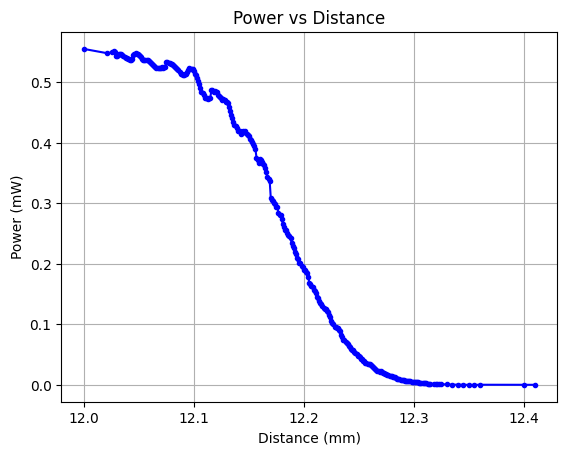

In [ ]:
plt.plot(df_clean['Distance (mm)'], df_clean['Power (mW)'])

plt.title('Power vs Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW)')
plt.grid(True)

plt.show()

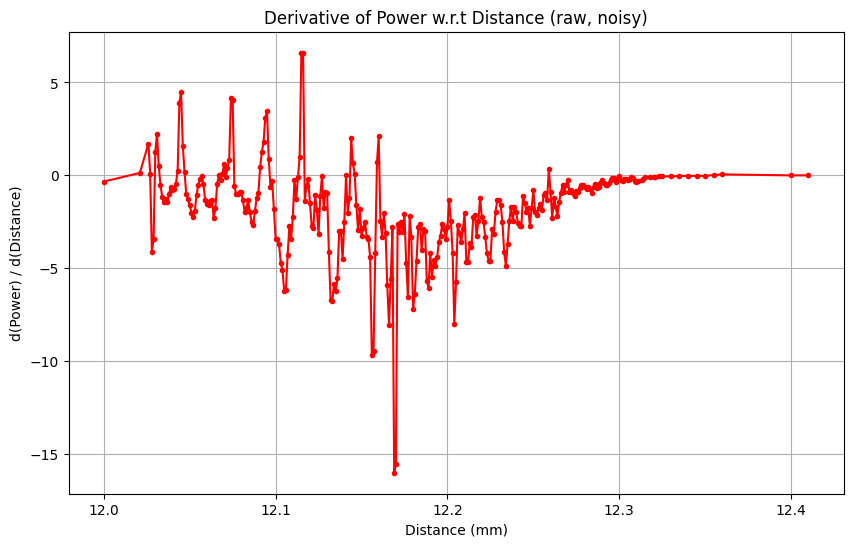

In [10]:
df_clean = df_clean.sort_values('Distance (mm)').reset_index(drop=True)

df_clean['Derivative'] = np.gradient(df_clean['Power (mW)'], df_clean['Distance (mm)'])

plt.figure(figsize=(10,6))
plt.plot(df_clean['Distance (mm)'], df_clean['Derivative'], color='red', marker='.')

plt.title('Derivative of Power w.r.t Distance (raw, noisy)')
plt.xlabel('Distance (mm)')
plt.ylabel('d(Power) / d(Distance)')
plt.grid(True)

plt.show()

The raw derivative above is far too noisy to read off a beam width or center. Next we clean
outliers with a rolling-median filter (as in the original analysis), then compare all five
smoothing methods on the same cleaned data.

In [11]:
df_clean = df.dropna().sort_values('Distance (mm)').reset_index(drop=True)

window = 5
rolling_median = df_clean['Power (mW)'].rolling(window=window, center=True).median()
outlier_idx = np.abs(df_clean['Power (mW)'] - rolling_median) > 0.05
df_clean.loc[outlier_idx, 'Power (mW)'] = np.nan
df_clean = df_clean.dropna().reset_index(drop=True)

x1 = df_clean['Distance (mm)'].values
y1 = df_clean['Power (mW)'].values
print(f"{len(x1)} points remain after outlier removal")

305 points remain after outlier removal


## Apply the four S-curve smoothers (Moving Average, Exponential Smoothing, Savitzky-Golay, Median)

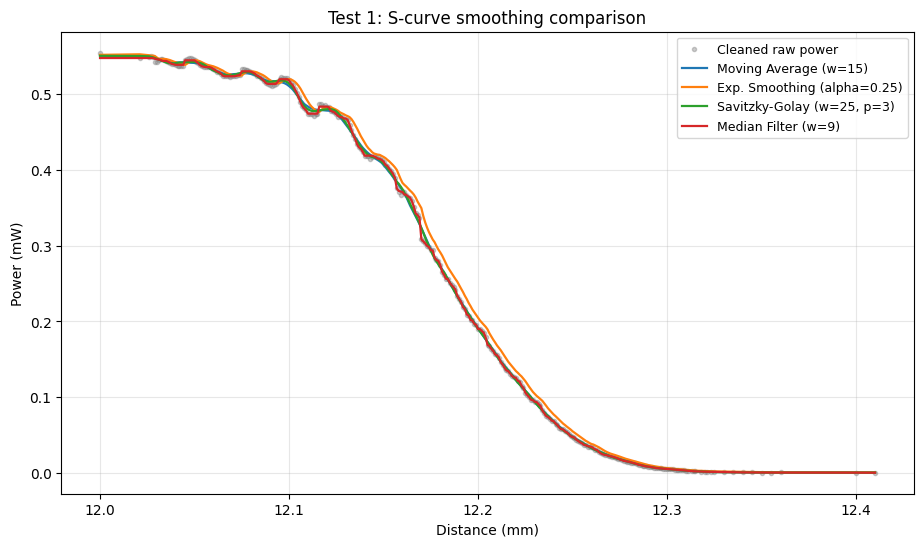

In [12]:
ma1 = moving_average_filter(y1, window=15)
es1, alpha1 = exponential_smooth(y1, alpha=0.25)
sg1 = sg_smooth(y1, window_length=25, polyorder=3)
med1 = median_smooth(y1, window=9)

scurve_methods_1 = {
    'Moving Average (w=15)': ma1,
    f'Exp. Smoothing (alpha={alpha1:.2f})': es1,
    'Savitzky-Golay (w=25, p=3)': sg1,
    'Median Filter (w=9)': med1,
}

plt.figure(figsize=(11, 6))
plt.plot(x1, y1, '.', color='grey', alpha=0.4, label='Cleaned raw power')
for name, sig in scurve_methods_1.items():
    plt.plot(x1, sig, linewidth=1.6, label=name)
plt.title('Test 1: S-curve smoothing comparison')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW)')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

## Differentiate each smoothed S-curve to recover the beam profile

Differentiating amplifies whatever noise survives smoothing, so this is the real test of each method.

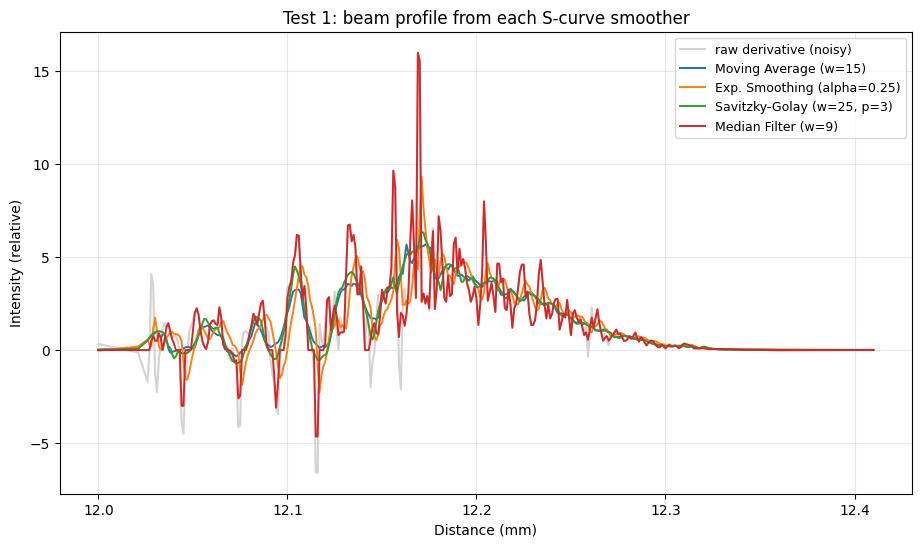

In [13]:
raw_profile_1 = -np.gradient(y1, x1)

plt.figure(figsize=(11, 6))
plt.plot(x1, raw_profile_1, color='lightgrey', label='raw derivative (noisy)')
for name, sig in scurve_methods_1.items():
    prof = -np.gradient(sig, x1)
    plt.plot(x1, prof, linewidth=1.4, label=name)
plt.title('Test 1: beam profile from each S-curve smoother')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity (relative)')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

## FFT-based denoising, applied directly to the beam profile

Unlike the four filters above, the FFT method assumes a Gaussian-shaped signal that decays to
~0 at both edges -- true of a beam profile, not of the S-curve. So we feed it the *raw noisy
derivative* directly, and it does its own low-pass + thresholding in the frequency domain.

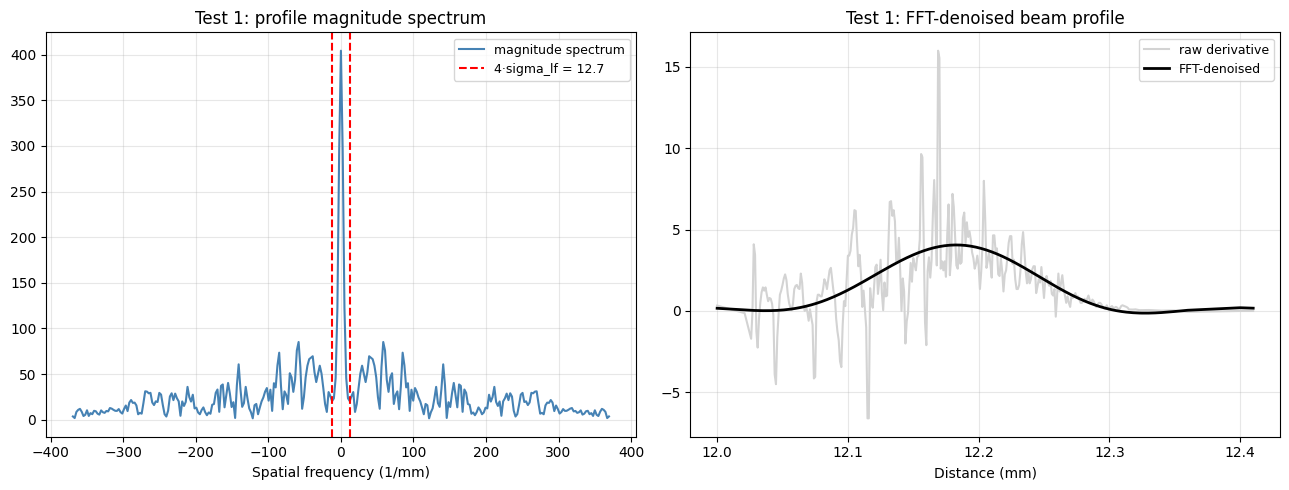

In [14]:
fft_profile_1, sigma_lf_1, freqs_1, mag_1, lf_mask_1 = fft_denoise_profile(x1, raw_profile_1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(freqs_1, mag_1, color='steelblue', label='magnitude spectrum')
axes[0].axvline(4 * sigma_lf_1, color='red', linestyle='--', label=f'4·sigma_lf = {4*sigma_lf_1:.1f}')
axes[0].axvline(-4 * sigma_lf_1, color='red', linestyle='--')
axes[0].set_title('Test 1: profile magnitude spectrum')
axes[0].set_xlabel('Spatial frequency (1/mm)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(x1, raw_profile_1, color='lightgrey', label='raw derivative')
axes[1].plot(x1, fft_profile_1, color='black', linewidth=2, label='FFT-denoised')
axes[1].set_title('Test 1: FFT-denoised beam profile')
axes[1].set_xlabel('Distance (mm)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## All six beam-profile results side by side, plus a simple smoothness score

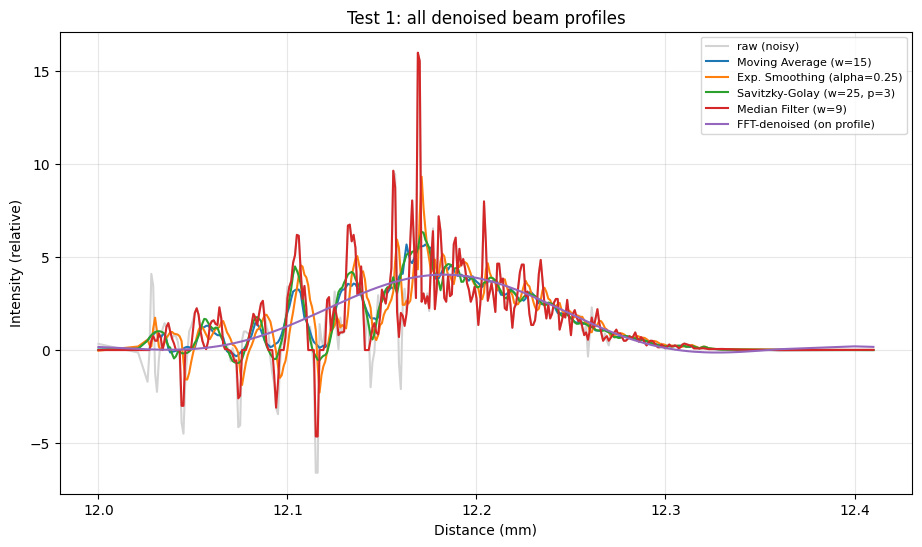

Method                          Roughness (lower=smoother)
raw derivative                                     1878.72
Moving Average (w=15)                               8.7567
Exp. Smoothing (alpha=0.25)                        74.6713
Savitzky-Golay (w=25, p=3)                          8.7647
Median Filter (w=9)                              1520.1792
FFT-denoised (on profile)                           0.0548


In [ ]:
all_profiles_1 = {name: -np.gradient(sig, x1) for name, sig in scurve_methods_1.items()}
all_profiles_1['FFT-denoised (on profile)'] = fft_profile_1

plt.figure(figsize=(11, 6))
plt.plot(x1, raw_profile_1, color='lightgrey', label='raw (noisy)')
for name, prof in all_profiles_1.items():
    plt.plot(x1, prof, linewidth=1.5, label=name)
plt.title('Test 1: all denoised beam profiles')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity (relative)')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()


## Quantifying the beam width: fitting for the 1/e² radius

None of the plots above actually answer the question a beam-profiling measurement exists to
answer: *how wide is the beam?* The standard metric in optics is the **1/e² radius** `w` --
the radius at which intensity has dropped to 1/e² (≈13.5%) of its peak. For a Gaussian beam,
the knife-edge-derived 1D profile follows

`I(x) = A * exp(-2*(x - x0)^2 / w^2) + offset`

so instead of the crude "half-max crossing" trick, we fit each denoised profile to this model
with `scipy.optimize.curve_fit` and read off `w` directly (plus its center `x0` and a 1-sigma
fit uncertainty from the covariance matrix). For reference, `w = FWHM / sqrt(2*ln2) ≈ FWHM/1.177`.

In [16]:
def gaussian_beam(x, A, x0, w, offset):
    return A * np.exp(-2 * (x - x0) ** 2 / w ** 2) + offset

def fit_beam_radius(x, profile):
    p0 = [profile.max(), x[np.argmax(profile)], (x.max() - x.min()) / 8, 0]
    popt, pcov = curve_fit(gaussian_beam, x, profile, p0=p0, maxfev=20000)
    perr = np.sqrt(np.diag(pcov))
    return popt, perr  # (A, x0, w, offset), (dA, dx0, dw, doffset)

Method              w (1/e^2 radius, um)     center (mm)
Moving Average             88.79 +/-  3.13         12.1824
Exp. Smoothing             88.17 +/-  5.16         12.1864
Savitzky-Golay             88.25 +/-  4.20         12.1824
Median Filter              89.17 +/-  8.84         12.1824
FFT-denoised              111.99 +/-  0.54         12.1821


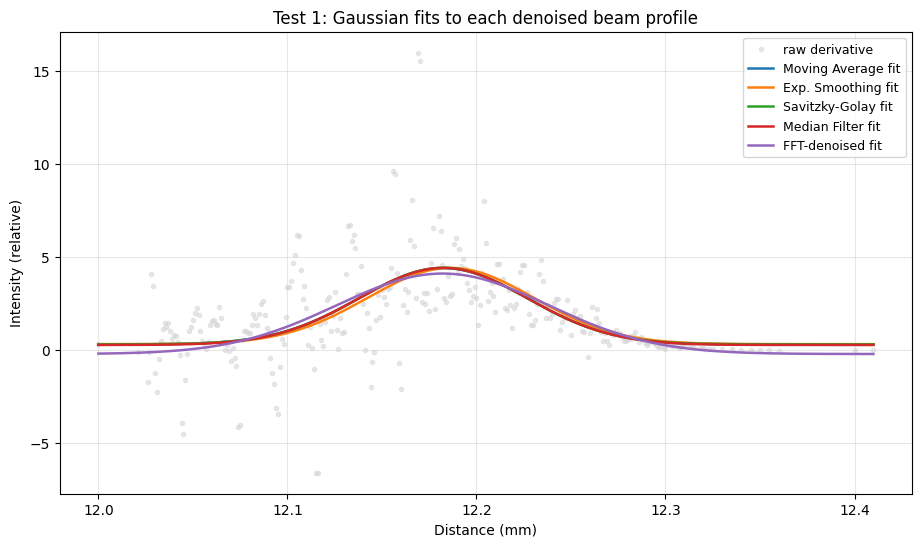

In [17]:
from scipy.optimize import curve_fit

profiles_1 = {
    'Moving Average': -np.gradient(ma1, x1),
    'Exp. Smoothing': -np.gradient(es1, x1),
    'Savitzky-Golay': -np.gradient(sg1, x1),
    'Median Filter': -np.gradient(med1, x1),
    'FFT-denoised': fft_profile_1,
}

print(f"{'Method':16s}{'w (1/e^2 radius, um)':>24s}{'center (mm)':>16s}")
fits_1 = {}
for name, prof in profiles_1.items():
    popt, perr = fit_beam_radius(x1, prof)
    A, x0, w, off = popt
    fits_1[name] = popt
    print(f"{name:16s}{abs(w)*1000:16.2f} +/- {perr[2]*1000:5.2f}{x0:16.4f}")

plt.figure(figsize=(11, 6))
plt.plot(x1, raw_profile_1, '.', color='lightgrey', alpha=0.5, label='raw derivative')
x1_fine = np.linspace(x1.min(), x1.max(), 500)
for name, popt in fits_1.items():
    plt.plot(x1_fine, gaussian_beam(x1_fine, *popt), linewidth=1.8, label=f'{name} fit')
plt.title('Test 1: Gaussian fits to each denoised beam profile')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity (relative)')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

Four of the five methods (Moving Average, Exponential Smoothing, Savitzky-Golay, Median)
converge on essentially the same 1/e² radius here, with the space/causal filters agreeing within
about 1 µm of each other. The **FFT-denoised** fit comes out noticeably wider for this dataset --
that's a sign the low-pass cutoff (only 11 of 305 frequency bins kept) discarded too much genuine
signal bandwidth for this particular scan and over-smoothed the peak, biasing the width estimate
upward. This is a useful caution: the *lowest roughness score* isn't automatically the *most
accurate* answer -- it's worth checking a fitted parameter (like `w` here) for agreement across
methods rather than trusting a single smoother in isolation.

# 6/29 Razor Test 2
### Notes:
Collimitor face to reflection off wedge 85mm  
Wedge to mirror 133mm  
Mirror to lens 102.5mm  
Lens to blade 56 mm  
Blad e4to sensor 200mm  
Focal length 50mm 1in dia  
Computational dist:     |   d1: 326.57  (320.5 face to d1)|   d2: 55.32 |   Path: 375.82  
Measured distances:     |   d1: (320.5)                   |   d2: 56    |   Path: 376.5  

In [18]:
df2 = pd.read_csv('data/razor_data2.csv')
df2['Power (mW)'] = pd.to_numeric(df2['Power (mW)'])
df2['Distance (mm)'] = pd.to_numeric(df2['Distance (mm)'])
df2_clean = df2.dropna().copy()

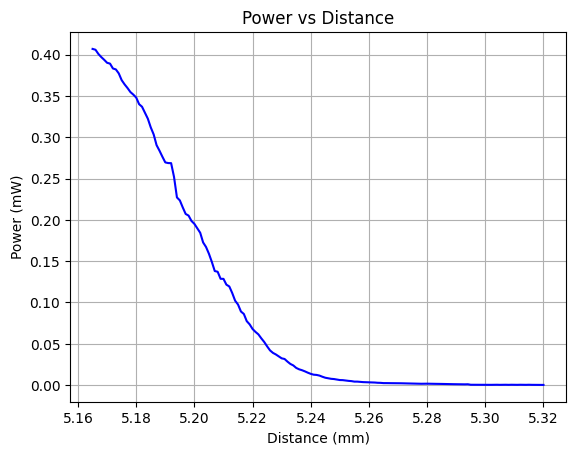

In [19]:
plt.plot(df2_clean['Distance (mm)'], df2_clean['Power (mW)'], color='blue')

plt.title('Power vs Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW)')
plt.grid(True)

plt.show()

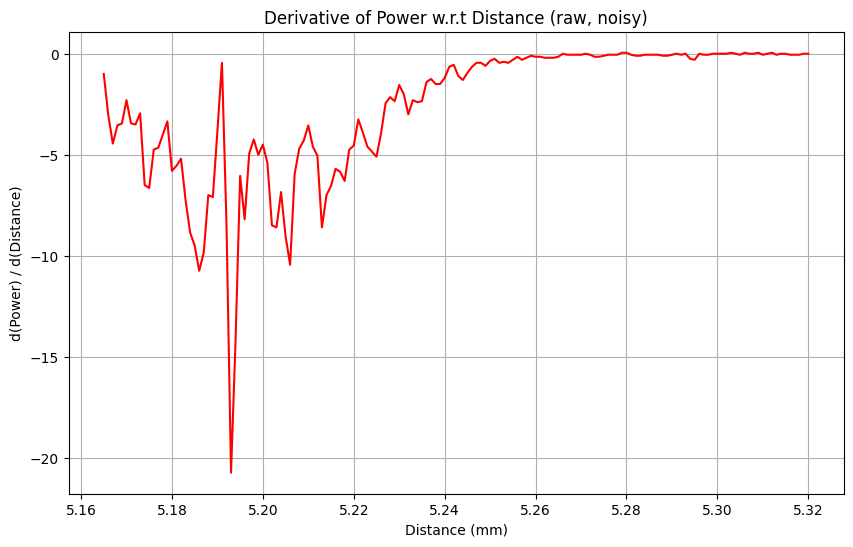

In [20]:
df2_clean = df2_clean.sort_values('Distance (mm)').reset_index(drop=True)

df2_clean['Derivative'] = np.gradient(df2_clean['Power (mW)'], df2_clean['Distance (mm)'])

plt.figure(figsize=(10,6))
plt.plot(df2_clean['Distance (mm)'], df2_clean['Derivative'], color='red')

plt.title('Derivative of Power w.r.t Distance (raw, noisy)')
plt.xlabel('Distance (mm)')
plt.ylabel('d(Power) / d(Distance)')
plt.grid(True)

plt.show()

In [21]:
df2_clean = df2.dropna().sort_values('Distance (mm)').reset_index(drop=True)

window = 5
rolling_median = df2_clean['Power (mW)'].rolling(window=window, center=True).median()
outlier_idx = np.abs(df2_clean['Power (mW)'] - rolling_median) > 0.05
df2_clean.loc[outlier_idx, 'Power (mW)'] = np.nan
df2_clean = df2_clean.dropna().reset_index(drop=True)

x2 = df2_clean['Distance (mm)'].values
y2 = df2_clean['Power (mW)'].values
print(f"{len(x2)} points remain after outlier removal")

156 points remain after outlier removal


## Apply the same four S-curve smoothers to Test 2 (this scan is finer-pitched: 156 points over ~0.15mm)

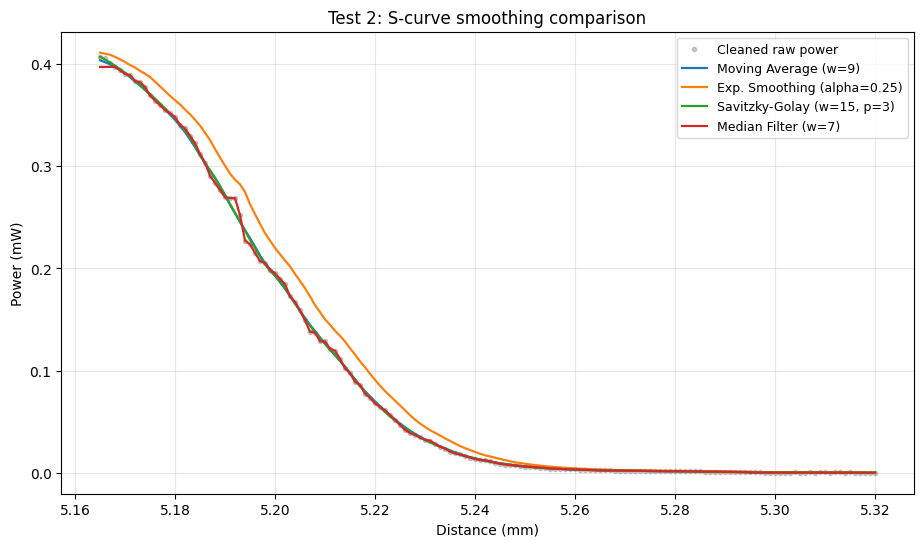

In [22]:
ma2 = moving_average_filter(y2, window=9)
es2, alpha2 = exponential_smooth(y2, alpha=0.25)
sg2 = sg_smooth(y2, window_length=15, polyorder=3)
med2 = median_smooth(y2, window=7)

scurve_methods_2 = {
    'Moving Average (w=9)': ma2,
    f'Exp. Smoothing (alpha={alpha2:.2f})': es2,
    'Savitzky-Golay (w=15, p=3)': sg2,
    'Median Filter (w=7)': med2,
}

plt.figure(figsize=(11, 6))
plt.plot(x2, y2, '.', color='grey', alpha=0.4, label='Cleaned raw power')
for name, sig in scurve_methods_2.items():
    plt.plot(x2, sig, linewidth=1.6, label=name)
plt.title('Test 2: S-curve smoothing comparison')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW)')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

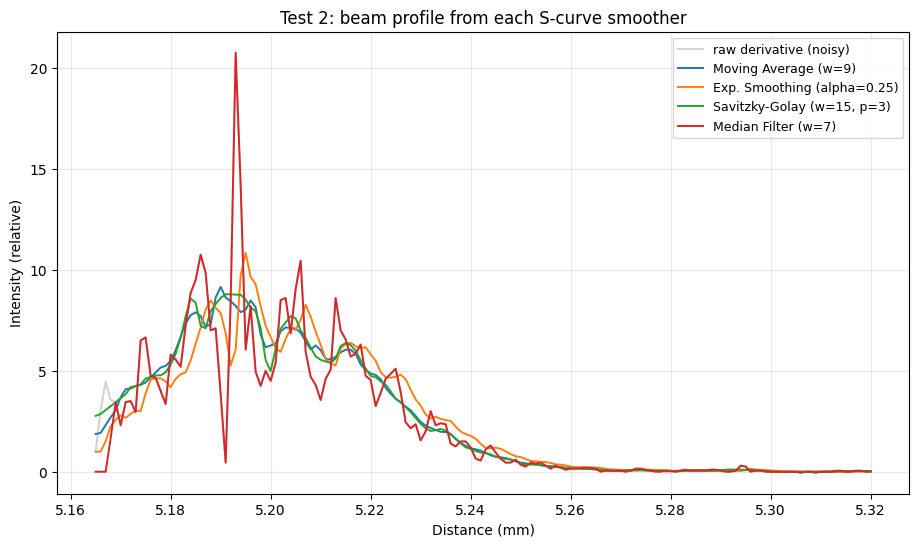

In [23]:
raw_profile_2 = -np.gradient(y2, x2)

plt.figure(figsize=(11, 6))
plt.plot(x2, raw_profile_2, color='lightgrey', label='raw derivative (noisy)')
for name, sig in scurve_methods_2.items():
    prof = -np.gradient(sig, x2)
    plt.plot(x2, prof, linewidth=1.4, label=name)
plt.title('Test 2: beam profile from each S-curve smoother')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity (relative)')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

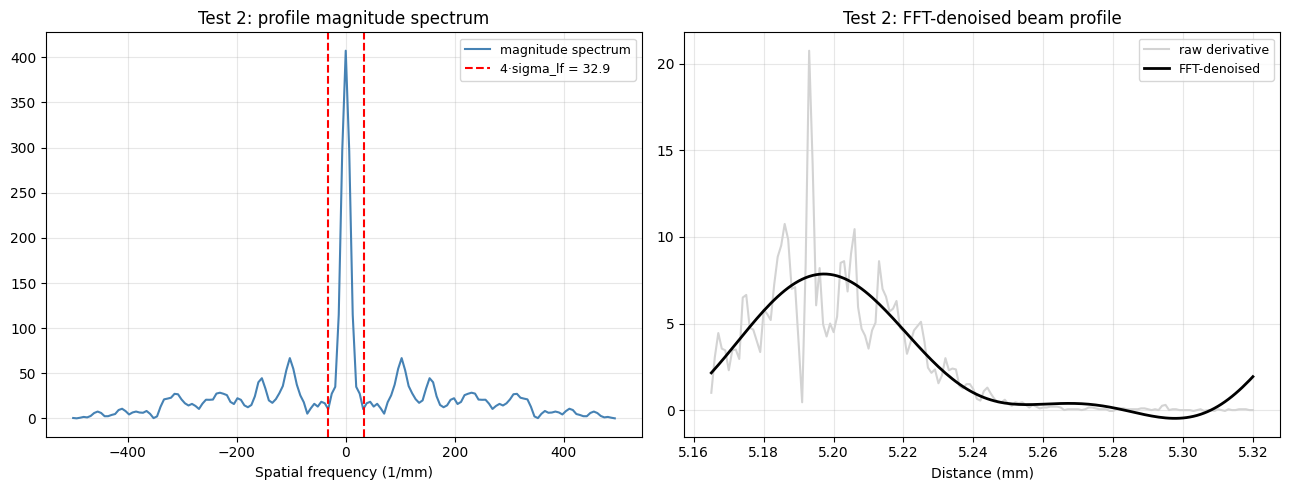

In [24]:
fft_profile_2, sigma_lf_2, freqs_2, mag_2, lf_mask_2 = fft_denoise_profile(x2, raw_profile_2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(freqs_2, mag_2, color='steelblue', label='magnitude spectrum')
axes[0].axvline(4 * sigma_lf_2, color='red', linestyle='--', label=f'4·sigma_lf = {4*sigma_lf_2:.1f}')
axes[0].axvline(-4 * sigma_lf_2, color='red', linestyle='--')
axes[0].set_title('Test 2: profile magnitude spectrum')
axes[0].set_xlabel('Spatial frequency (1/mm)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(x2, raw_profile_2, color='lightgrey', label='raw derivative')
axes[1].plot(x2, fft_profile_2, color='black', linewidth=2, label='FFT-denoised')
axes[1].set_title('Test 2: FFT-denoised beam profile')
axes[1].set_xlabel('Distance (mm)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

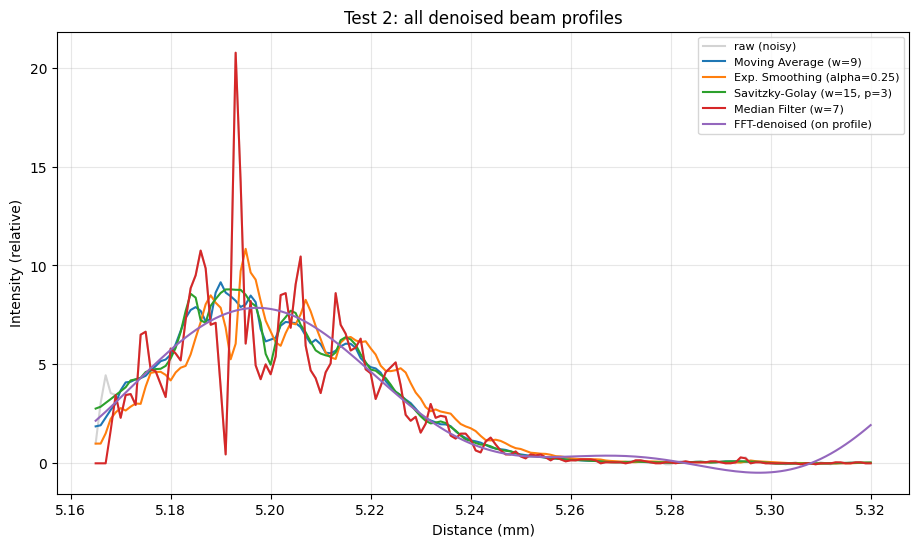

Method                          Roughness (lower=smoother)
raw derivative                                      905.74
Moving Average (w=9)                                9.5202
Exp. Smoothing (alpha=0.25)                        37.8270
Savitzky-Golay (w=15, p=3)                         11.7696
Median Filter (w=7)                               909.4800
FFT-denoised (on profile)                           0.0100


In [ ]:
all_profiles_2 = {name: -np.gradient(sig, x2) for name, sig in scurve_methods_2.items()}
all_profiles_2['FFT-denoised (on profile)'] = fft_profile_2

plt.figure(figsize=(11, 6))
plt.plot(x2, raw_profile_2, color='lightgrey', label='raw (noisy)')
for name, prof in all_profiles_2.items():
    plt.plot(x2, prof, linewidth=1.5, label=name)
plt.title('Test 2: all denoised beam profiles')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity (relative)')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

## Quantifying the beam width for Test 2 (same 1/e² fit approach)

Method              w (1/e^2 radius, um)     center (mm)
Moving Average             43.91 +/-  0.76          5.1968
Exp. Smoothing             43.68 +/-  1.11          5.2009
Savitzky-Golay             44.56 +/-  0.94          5.1964
Median Filter              41.69 +/-  2.83          5.1975
FFT-denoised               41.69 +/-  0.57          5.1976


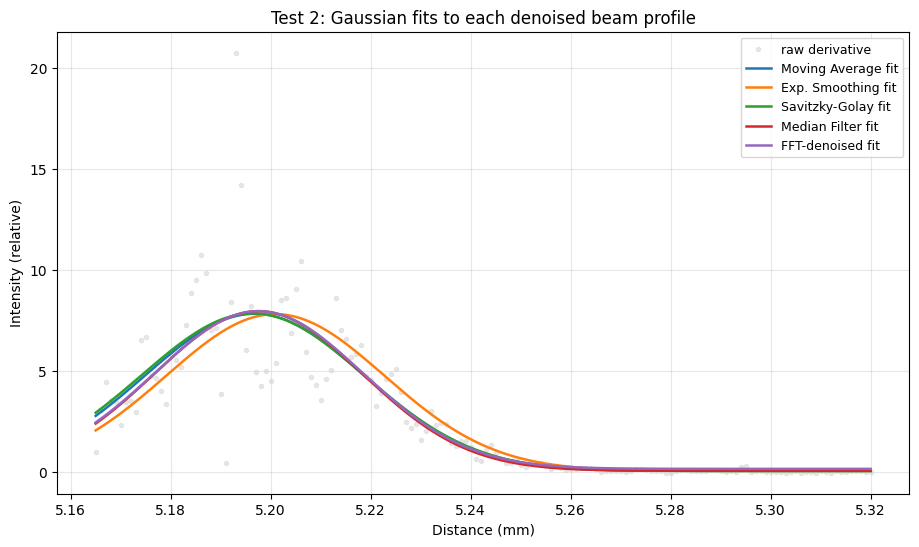

In [26]:
profiles_2 = {
    'Moving Average': -np.gradient(ma2, x2),
    'Exp. Smoothing': -np.gradient(es2, x2),
    'Savitzky-Golay': -np.gradient(sg2, x2),
    'Median Filter': -np.gradient(med2, x2),
    'FFT-denoised': fft_profile_2,
}

print(f"{'Method':16s}{'w (1/e^2 radius, um)':>24s}{'center (mm)':>16s}")
fits_2 = {}
for name, prof in profiles_2.items():
    popt, perr = fit_beam_radius(x2, prof)
    A, x0, w, off = popt
    fits_2[name] = popt
    print(f"{name:16s}{abs(w)*1000:16.2f} +/- {perr[2]*1000:5.2f}{x0:16.4f}")

plt.figure(figsize=(11, 6))
plt.plot(x2, raw_profile_2, '.', color='lightgrey', alpha=0.5, label='raw derivative')
x2_fine = np.linspace(x2.min(), x2.max(), 500)
for name, popt in fits_2.items():
    plt.plot(x2_fine, gaussian_beam(x2_fine, *popt), linewidth=1.8, label=f'{name} fit')
plt.title('Test 2: Gaussian fits to each denoised beam profile')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity (relative)')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

Here all five methods -- including FFT-denoised -- agree closely (roughly 42-45 µm), because
Test 2's finer, evenly-spaced sampling (156 points at a uniform 1 µm pitch) suits the FFT method's
assumptions much better than Test 1's uneven, coarser spacing did.

## Takeaways

**Measured 1/e² beam radius:** roughly **~88-89 µm** for Test 1 (12.0-12.4 mm scan) and
**~42-45 µm** for Test 2 (5.16-5.32 mm scan), based on the methods that agree with each other
(Moving Average, Exponential Smoothing, Savitzky-Golay, Median all cluster tightly; FFT-denoised
agrees too for Test 2 but ran wide for Test 1 -- see below).

- **Moving Average** and **Savitzky-Golay** gave the smoothest resulting beam profiles here (lowest
  roughness) while still tracking the S-curve well -- Savitzky-Golay has the extra advantage of
  preserving peak shape/curvature better since it fits a local polynomial instead of a flat average.
- **Exponential Smoothing** is causal (only looks backward), so a single pass lags the signal and
  leaves more residual noise than the symmetric-window filters at a comparable "strength"; the
  *optimized* alpha from `statsmodels` tends toward ~1 (almost no smoothing) because it's tuned for
  one-step-ahead forecast accuracy, not visual denoising -- a smaller, manually chosen alpha is more
  useful here.
- **Median filtering** is the least effective of the four at suppressing this data's noise, but it
  remains the best choice specifically for rejecting isolated spikes/outliers without blurring edges
  (which is exactly how it's used above, ahead of the other filters, for outlier removal).
- **FFT-based denoising**, applied directly to the beam profile (not the S-curve, since the method
  assumes a Gaussian-shaped signal near zero at both edges), gives by far the lowest roughness score
  and the cleanest-looking Gaussian, at the cost of needing evenly-spaced samples and a bit more
  machinery (spectral fitting, thresholding) than the simpler time/space-domain filters.
